In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
INVOICE_NO_COL = "Invoice_No."
INVOICE_DATE_COL = "Invoice Date"
STANDARD_RATE_COL = "Standard Rate"
INVOICE_RATE_COL = "Invoice Rate"
QUANTITY_COL = "Invoice Qty"
DISCOUNT_COL = "Disc.Per"
TRANSPORTER_NAME_COL = "TransporterName"
DESTINATION_COL = "Destination"
ITEM_CODE_COL = "Item_code"
AGG_COL = "Amount"
PRODUCT_COL = "SubMainGroup"
GST_COL = "Gst_No"
CUSTOMER_COL = "SupplierName"
columns_of_interest = [
    INVOICE_NO_COL,
    INVOICE_DATE_COL,
    CUSTOMER_COL,
    GST_COL,
    ITEM_CODE_COL,
    PRODUCT_COL,
    QUANTITY_COL,
    STANDARD_RATE_COL,
    INVOICE_RATE_COL,
    DISCOUNT_COL,
    TRANSPORTER_NAME_COL,
    DESTINATION_COL,
    AGG_COL
]

In [3]:
EXCEL_NAME = "Sales Invoice Register 2020-2026 Mitesh 260508.xlsx"
df = pd.read_excel(EXCEL_NAME, header=0)

In [4]:
FILE_NAME = "Sales Invoice Register 2014 2020 Mitesh 260509.xlsx"
df_old = pd.read_excel(FILE_NAME, header=0)

In [5]:
df_old.rename(columns={'Sub Main Group':'SubMainGroup'}, inplace=True)

In [6]:
df_20_25 = df[columns_of_interest]
df_14_20 = df_old[columns_of_interest]

In [7]:
df_of_interest = pd.concat([df_14_20, df_20_25], ignore_index=True)
df_of_interest[INVOICE_DATE_COL] = pd.to_datetime(df_of_interest[INVOICE_DATE_COL], errors="coerce")
df_of_interest = df_of_interest.sort_values(INVOICE_DATE_COL, na_position="last").reset_index(drop=True)
df_of_interest.to_excel("df-sales.xlsx", index=False)
df_of_interest

,Invoice_No.,Invoice Date,SupplierName,Gst_No,Item_code,SubMainGroup,Invoice Qty,Standard Rate,Invoice Rate,Disc.Per,TransporterName,Destination,Amount
0,SI00000009,2014-04-01,ASIAN TUBE LTD.(UNIT-I),24AABCA2797E1ZV,PCH-20-GR2-PP,PIPE CLAMP,10.0,0.0,81.0,30.0,,NaN,567.00
1,SI00000008,2014-04-01,SIT FLEXIBLE HOSE PVT LTD,24AAKCS2010H1ZS,H--4WE-10-D-G24,H - SOL. OPE. DIRECTIONAL VALVE,2.0,0.0,5110.0,27.0,,NaN,7460.60
2,SI00000009,2014-04-01,ASIAN TUBE LTD.(UNIT-I),24AABCA2797E1ZV,"DS-1"" BSP",DOWTY SEAL,10.0,0.0,10.0,30.0,,NaN,70.00
3,SI00000009,2014-04-01,ASIAN TUBE LTD.(UNIT-I),24AABCA2797E1ZV,"DS-1/2"" BSP",DOWTY SEAL,10.0,0.0,7.0,30.0,,NaN,49.00
4,SI00000009,2014-04-01,ASIAN TUBE LTD.(UNIT-I),24AABCA2797E1ZV,"HN-1"" BSPX1"" BSP",HEX NIPPLE,10.0,0.0,94.0,30.0,,NaN,658.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
561809,SI10001637,2026-05-14,CORE HYDRAULICS PVT LTD,24AABCH4876M1Z7,BHA-130-082.6-100-106.2-90-M10,BELL HOUSING,15.0,750.0,815.0,12.0,-,NaN,10758.00
561810,SI10001636,2026-05-14,LEXUS HYCON PRIVATE LIMITED,24AACCL2622G1ZZ,HL--TIF2-04 B-P25,HL - RETURN LINE FILTER,1.0,1217.0,1217.0,25.0,-,NaN,912.75
561811,SI10001636,2026-05-14,LEXUS HYCON PRIVATE LIMITED,24AACCL2622G1ZZ,FSB-05-N-NC,FILLER BREATHER ASSEMBLY,1.0,260.0,260.0,30.0,-,NaN,182.00
561812,SI10001652,2026-05-14,SN HYDRAULICS(MAHARASHTRA),27EKHPS7454F1ZN,JT-28--28+13.45--40+40,GEAR COUPLING WITH BORE & KEYWAY,10.0,530.0,530.0,30.0,-,NaN,3710.00


In [4]:
df_of_interest = pd.read_excel('df-sales.xlsx')

In [5]:
contact_sr = pd.read_excel("Contact_SR.xlsx")

In [9]:
TAX_ID_COL = "Tax ID"
SALESPERSON_COL = "Salesperson"

gst_salesperson = (
    contact_sr[[TAX_ID_COL, SALESPERSON_COL]]
    .dropna(subset=[TAX_ID_COL, SALESPERSON_COL])
    .assign(
        **{
            TAX_ID_COL: lambda d: d[TAX_ID_COL].astype(str).str.strip().str.upper(),
            SALESPERSON_COL: lambda d: d[SALESPERSON_COL].astype(str).str.strip(),
        }
    )
    .query(f'`{TAX_ID_COL}` != "NAN"')
    .groupby(TAX_ID_COL, as_index=False)[SALESPERSON_COL]
    .agg(lambda s: s.mode().iat[0] if len(s.mode()) else s.iloc[0])
    .rename(columns={TAX_ID_COL: GST_COL})
)

df_of_interest = df_of_interest.copy()
df_of_interest[GST_COL] = df_of_interest[GST_COL].astype(str).str.strip().str.upper()

df_of_interest = df_of_interest.merge(gst_salesperson, on=GST_COL, how="left")
df_of_interest

,Invoice_No.,Invoice Date,SupplierName,Gst_No,Item_code,SubMainGroup,Invoice Qty,Standard Rate,Invoice Rate,Disc.Per,TransporterName,Destination,Amount,Salesperson
0,SI00000009,2014-04-01,ASIAN TUBE LTD.(UNIT-I),24AABCA2797E1ZV,PCH-20-GR2-PP,PIPE CLAMP,10.0,0.0,81.0,30.0,,NaN,567.00,07-NIRMAL
1,SI00000008,2014-04-01,SIT FLEXIBLE HOSE PVT LTD,24AAKCS2010H1ZS,H--4WE-10-D-G24,H - SOL. OPE. DIRECTIONAL VALVE,2.0,0.0,5110.0,27.0,,NaN,7460.60,04-BHADRESH
2,SI00000009,2014-04-01,ASIAN TUBE LTD.(UNIT-I),24AABCA2797E1ZV,"DS-1"" BSP",DOWTY SEAL,10.0,0.0,10.0,30.0,,NaN,70.00,07-NIRMAL
3,SI00000009,2014-04-01,ASIAN TUBE LTD.(UNIT-I),24AABCA2797E1ZV,"DS-1/2"" BSP",DOWTY SEAL,10.0,0.0,7.0,30.0,,NaN,49.00,07-NIRMAL
4,SI00000009,2014-04-01,ASIAN TUBE LTD.(UNIT-I),24AABCA2797E1ZV,"HN-1"" BSPX1"" BSP",HEX NIPPLE,10.0,0.0,94.0,30.0,,NaN,658.00,07-NIRMAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
561809,SI10001637,2026-05-14,CORE HYDRAULICS PVT LTD,24AABCH4876M1Z7,BHA-130-082.6-100-106.2-90-M10,BELL HOUSING,15.0,750.0,815.0,12.0,-,NaN,10758.00,06-RAVI
561810,SI10001636,2026-05-14,LEXUS HYCON PRIVATE LIMITED,24AACCL2622G1ZZ,HL--TIF2-04 B-P25,HL - RETURN LINE FILTER,1.0,1217.0,1217.0,25.0,-,NaN,912.75,07-NIRMAL
561811,SI10001636,2026-05-14,LEXUS HYCON PRIVATE LIMITED,24AACCL2622G1ZZ,FSB-05-N-NC,FILLER BREATHER ASSEMBLY,1.0,260.0,260.0,30.0,-,NaN,182.00,07-NIRMAL
561812,SI10001652,2026-05-14,SN HYDRAULICS(MAHARASHTRA),27EKHPS7454F1ZN,JT-28--28+13.45--40+40,GEAR COUPLING WITH BORE & KEYWAY,10.0,530.0,530.0,30.0,-,NaN,3710.00,06-RAVI


In [10]:
df_of_interest[df_of_interest["SupplierName"].str.contains("MARUTI IND")]

,Invoice_No.,Invoice Date,SupplierName,Gst_No,Item_code,SubMainGroup,Invoice Qty,Standard Rate,Invoice Rate,Disc.Per,TransporterName,Destination,Amount,Salesperson
46120,SI00002376,2015-06-19,MARUTI INDUSTRIES(ODHAV),24AQWPB7806P1Z6,EDM-19-10-31,EDM PAPER FILTER,1.0,0.0,690.0,10.0,,NaN,621.00,07-NIRMAL
53038,SI00004175,2015-08-24,MARUTI INDUSTRIES(ODHAV),24AQWPB7806P1Z6,EDM-19-10-31,EDM PAPER FILTER,2.0,0.0,690.0,10.0,,NaN,1242.00,07-NIRMAL
79762,SI00001240,2016-05-16,MARUTI INDUSTRIES(ODHAV),24AQWPB7806P1Z6,EDM-19-10-31,EDM PAPER FILTER,2.0,0.0,690.0,10.0,,NaN,1242.00,07-NIRMAL
107679,SI00009098,2017-03-10,MARUTI INDUSTRIES(ODHAV),24AQWPB7806P1Z6,EDM-19-10-31,EDM PAPER FILTER,3.0,0.0,690.0,10.0,,NaN,1863.00,07-NIRMAL
107855,SI00009159,2017-03-12,MARUTI INDUSTRIES ( SURAT),24AQQPR1137H1ZP,DPRH-06-T-100-C,PRESSURE RELIEF VALVE,15.0,0.0,925.0,30.0,dummy,NaN,9712.50,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
561239,SI10001477,2026-05-11,MARUTI INDUSTRIES (GANGOTRI ESTATE),24AMOPP3603Q1ZJ,FLG6-03,OIL LEVEL INDICATOR,3.0,265.0,265.0,27.0,-,NaN,580.35,06-RAVI
561307,SI10001477,2026-05-11,MARUTI INDUSTRIES (GANGOTRI ESTATE),24AMOPP3603Q1ZJ,"SC3-07X3/4""",SUCTION STRAINER,6.0,215.0,215.0,27.0,-,NaN,941.70,06-RAVI
561316,SI10001477,2026-05-11,MARUTI INDUSTRIES (GANGOTRI ESTATE),24AMOPP3603Q1ZJ,BHAK-180-082.6-110-106.2-90-M10-J28-28+13.45-4...,BELL HOUSING,3.0,1550.0,1550.0,5.0,-,NaN,4417.50,06-RAVI
561336,SI10001477,2026-05-11,MARUTI INDUSTRIES (GANGOTRI ESTATE),24AMOPP3603Q1ZJ,0P-3006+0P-3006--C-P-S-TT-B1-N,GEAR PUMP ( MULTI COMBINATION ),3.0,8600.0,8600.0,20.0,-,NaN,20640.00,06-RAVI


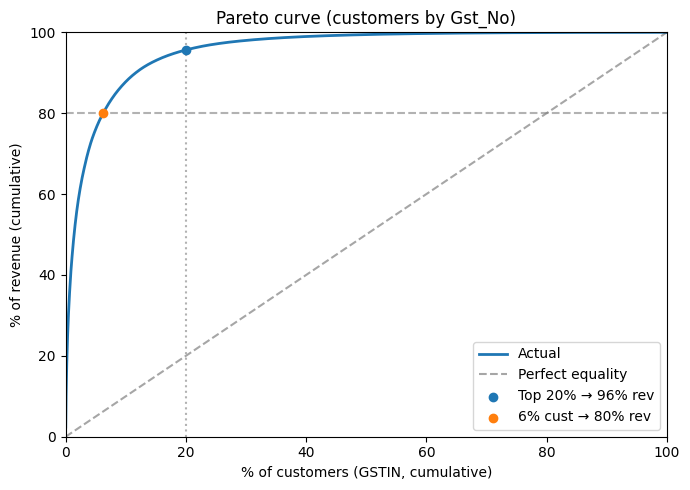

In [7]:
# 80/20 (Pareto): customers unique by Gst_No
_pareto = df_of_interest.copy()
_pareto[GST_COL] = _pareto[GST_COL].astype(str).str.strip().str.upper()
_pareto = _pareto[_pareto[GST_COL].notna() & (_pareto[GST_COL] != "NAN") & (_pareto[GST_COL] != "")]
_pareto[AGG_COL] = pd.to_numeric(_pareto[AGG_COL], errors="coerce").fillna(0.0)

cust_rev = (
    _pareto.groupby(GST_COL, observed=True)[AGG_COL]
    .sum()
    .sort_values(ascending=False)
)
n_customers = len(cust_rev)
total_rev = cust_rev.sum()
cum_rev_pct = cust_rev.cumsum() / total_rev * 100

top_20_n = max(1, int(np.ceil(0.20 * n_customers)))
pct_rev_from_top_20 = cust_rev.iloc[:top_20_n].sum() / total_rev * 100
customers_for_80_rev = int(np.searchsorted(cum_rev_pct.values, 80, side="left")) + 1
pct_customers_for_80_rev = customers_for_80_rev / n_customers * 100

pareto_check = pd.DataFrame(
    {
        "check": [
            "Unique customers (GSTIN)",
            "Total revenue",
            "Top 20% of customers → share of revenue",
            "Share of customers needed to reach 80% revenue",
            "Classic 80/20 holds? (≈20% cust → ≈80% rev)",
        ],
        "result": [
            f"{n_customers:,}",
            f"₹{total_rev:,.0f}",
            f"{pct_rev_from_top_20:.1f}% (top {top_20_n:,} GSTINs)",
            f"{pct_customers_for_80_rev:.1f}% ({customers_for_80_rev:,} GSTINs)",
            "Yes" if 75 <= pct_rev_from_top_20 <= 85 and 15 <= pct_customers_for_80_rev <= 25 else "No (more concentrated)",
        ],
    }
)
pareto_check

fig, ax = plt.subplots(figsize=(7, 5))
cust_pct = np.arange(1, n_customers + 1) / n_customers * 100
ax.plot(cust_pct, cum_rev_pct.values, lw=2, label="Actual")
ax.plot([0, 100], [0, 100], "k--", alpha=0.35, label="Perfect equality")
ax.axhline(80, color="gray", ls="--", alpha=0.6)
ax.axvline(20, color="gray", ls=":", alpha=0.6)
ax.scatter([20], [pct_rev_from_top_20], zorder=5, label=f"Top 20% → {pct_rev_from_top_20:.0f}% rev")
ax.scatter([pct_customers_for_80_rev], [80], zorder=5, label=f"{pct_customers_for_80_rev:.0f}% cust → 80% rev")
ax.set_xlabel("% of customers (GSTIN, cumulative)")
ax.set_ylabel("% of revenue (cumulative)")
ax.set_title("Pareto curve (customers by Gst_No)")
ax.legend(loc="lower right")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

In [ ]:
df_of_interest["Gst_No"].unique()

<ArrowStringArray>
['24AABCA2797E1ZV', '24AAKCS2010H1ZS', '24AABCA8236G1ZX', '24ACNPD2610G2Z4',
 '24ACKPC0936B1ZA',               nan, '24AAEFA2637D1Z1', '24AAHFP5335J1Z5',
 '24AACFP1776A1ZO', '24AADFJ0645H1ZP',
 ...
 '24ABGPC6343K1ZS', '24ADNPB9213C1Z0', '23APJPP6882K1Z9', '27ODLPK2063P1ZO',
 '24CZMPP2448E1Z9', '24AFAPU0355H1ZN', '33AACCG1441L1ZV', '24AAEFI3982M1Z0',
 '24ABIPP6971E2ZF', '24AAFFS4358C1ZE']
Length: 7950, dtype: str

In [11]:
0.2 * 7950

1590.0

In [12]:
1590/4000

0.3975